In [6]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
#coffea output file
f_sig = "../coffea/Withxclean_2022/ERE_Withxclean.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
sig_histo.keys()

dict_keys(['gen_vxy1', 'gen_vxy10', 'gen_vxy100', 'gen_ele_pt', 'gen_ele_eta', 'gen_ele_phi', 'gen_ele_dR', 'gen_ele_vxy1', 'gen_ele_vxy10', 'gen_ele_vxy100', 'mindR', 'match_ele_gen_pt', 'match_ele_gen_vxy1', 'match_ele_gen_vxy10', 'match_ele_gen_vxy100', 'gen_ele_pt_vs_vxy1', 'match_ele_gen_pt_vs_vxy1', 'PFMET', 'PFMET_vs_genMET', 'cutDesc', 'cutflow', 'cutflow_cts', 'cutflow_nevts', 'cutflow_vtx_matched'])

Saved: ./plots/signal_2022/pt.png
Total number of electrons with dR(low pT ele, regular ele)<0.05 at the coffea stage= 47.0


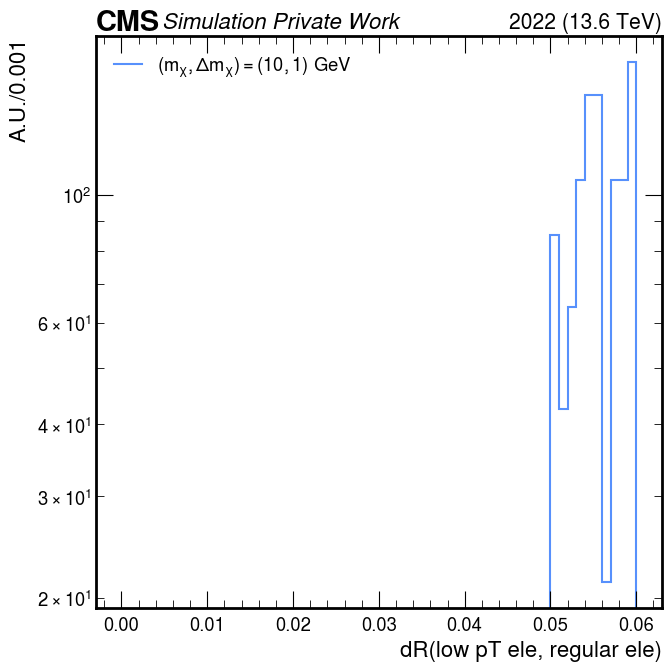

In [8]:
fig, ax = plt.subplots(figsize=(7,7))


delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable': 'mindR',
    'cut': 'cut0',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': [0,0.09],     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "dR(low pT ele, regular ele)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'pt.png'
}



#signal points
m1=10


counts = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)

# Plot for variables signal points
# for ctau in ctaus:
#     ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)



# results = [
#     ptools.plot_signal_1D_match(
#         sig_histo, m1, delta, ctau,
#         plot_dict, style_dict,
#         match_type='L', passID=1
#     )
#     for m1 in m1s
# ]

# counts, edges = zip(*results)

# counts = np.array(counts)     # shape: (n_m1, n_bins)
# edges  = np.array(edges)      # shape: (n_m1, n_edges)


# mask = counts != 0

# bins_x = (edges[:, :-1] + edges[:, 1:])*(0.5)

# counts_nonzero_den = np.where(mask, counts, np.nan)
# edges_nonzero_den  = np.where(mask, bins_x, np.nan)

total = np.sum(counts)
print ("Total number of electrons with dR(low pT ele, regular ele)<0.05 at the coffea stage=", total)
